# Importing Libraries

In [1]:
#importing require python packages and classes
import os
import cv2
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import  MaxPooling2D
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, GlobalAveragePooling2D, BatchNormalization
from keras.layers import Convolution2D
from tensorflow.keras.models import Sequential
import pickle
from tensorflow.keras.applications import VGG16 #loading VGG16 as based classifier
from tensorflow.keras.applications import VGG19 #loading VGG19 as extension classifier
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn import svm
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

Using TensorFlow backend.


# Importing Dataset

Dataset Loading Completed
Total images found in dataset : 39375
Classes found in dataset is Fire & No-Fire


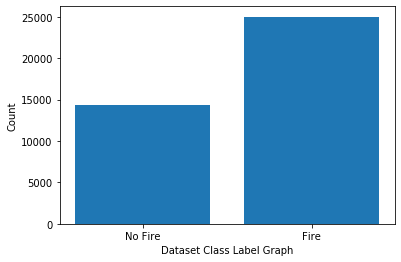

In [2]:
#load dataset images
if os.path.exists('model/X.txt.npy'): #if dataset already process then load it
    X = np.load('model/X.txt.npy')
    Y = np.load('model/Y.txt.npy')
else: #if not process then process, saved and load for future execution
    X = []
    Y = []
    path = 'Dataset'
    for root, dirs, directory in os.walk(path):#loop all images in dataset
        for j in range(len(directory)):
            name = os.path.basename(root)
            if 'Thumbs.db' not in directory[j]:
                img = cv2.imread(root+"/"+directory[j]) #read image
                img = cv2.resize(img, (32,32)) #resize image
                im2arr = np.array(img)
                im2arr = im2arr.reshape(32,32,3)
                X.append(im2arr) #add images to array
                if name == "Fire": #if fire then set label as 1 else 0 for non fire
                    Y.append(1)
                else:
                    Y.append(0)
    X = np.asarray(X)
    Y = np.asarray(Y)
    np.save('model/X.txt',X)
    np.save('model/Y.txt',Y)
print("Dataset Loading Completed")
print("Total images found in dataset : "+str(X.shape[0]))
print("Classes found in dataset is Fire & No-Fire")
unqiue, count = np.unique(Y, return_counts = True)
height = count
bars = ['No Fire', 'Fire']
y_pos = np.arange(len(bars))
plt.bar(y_pos, height)
plt.xticks(y_pos, bars)
plt.xlabel("Dataset Class Label Graph")
plt.ylabel("Count")
plt.show()

# EDA

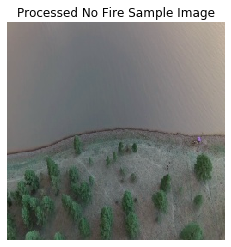

In [3]:
#display no fire image
no_fire = cv2.imread("Dataset/No_Fire/lake_resized_lake_frame22.jpg")
plt.imshow(no_fire)
plt.title('Processed No Fire Sample Image')
plt.axis('off')
plt.show()

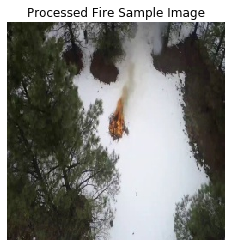

In [4]:
#display fire image
fire = cv2.imread("Dataset/Fire/resized_frame1.jpg")
plt.imshow(cv2.cvtColor(fire, cv2.COLOR_RGB2BGR))
plt.title('Processed Fire Sample Image')
plt.axis('off')
plt.show()

In [5]:
#dataset preprocessing such as shuffling and normalization
X = X.astype('float32')
X = X/255 #normalizing images
indices = np.arange(X.shape[0])
np.random.shuffle(indices)#shuffling images
X = X[indices]
Y = Y[indices]
Y = to_categorical(Y)
print("Dataset Normalization & Shuffling Process completed")

Dataset Normalization & Shuffling Process completed


In [6]:
#now splitting dataset into train & test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2) #split dataset into train and test
print()
print("Dataset train & test split as 80% dataset for training and 20% for testing")
print("Training Size (80%): "+str(X_train.shape[0])) #print training and test size
print("Testing Size (20%): "+str(X_test.shape[0]))
print()


Dataset train & test split as 80% dataset for training and 20% for testing
Training Size (80%): 31500
Testing Size (20%): 7875



In [7]:
#define global variables to calculate and store accuracy and other metrics
precision = []
recall = []
fscore = []
accuracy = []

In [8]:
#function to calculate various metrics such as accuracy, precision etc
def calculateMetrics(algorithm, predict, testY):
    p = precision_score(testY, predict,average='macro') * 100
    r = recall_score(testY, predict,average='macro') * 100
    f = f1_score(testY, predict,average='macro') * 100
    a = accuracy_score(testY,predict)*100     
    print()
    print(algorithm+' Accuracy  : '+str(a))
    print(algorithm+' Precision   : '+str(p))
    print(algorithm+' Recall      : '+str(r))
    print(algorithm+' FMeasure    : '+str(f))    
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    labels = ["No Fire", "Fire"]
    conf_matrix = confusion_matrix(testY, predict) 
    plt.figure(figsize =(5, 5)) 
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g");
    ax.set_ylim([0,len(labels)])
    plt.title(algorithm+" Confusion matrix") 
    plt.ylabel('True class') 
    plt.xlabel('Predicted class') 
    plt.show()

# SVM


SVM Accuracy  : 99.77142857142857
SVM Precision   : 99.79062029501569
SVM Recall      : 99.71228842643372
SVM FMeasure    : 99.75124847818469


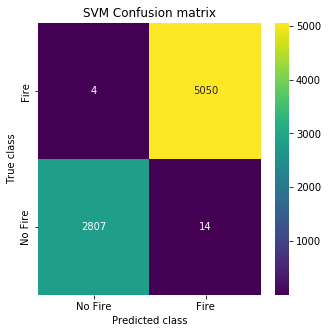

In [9]:
#now train SVM algorithm on color features
X_train1 = np.reshape(X_train, (X_train.shape[0], (X_train.shape[1] * X_train.shape[2] * X_train.shape[3])))
X_test1 = np.reshape(X_test, (X_test.shape[0], (X_test.shape[1] * X_test.shape[2] * X_test.shape[3])))
y_train1 = np.argmax(y_train, axis=1)
y_test1 = np.argmax(y_test, axis=1)
svm_cls = svm.SVC(kernel="rbf")
svm_cls.fit(X_train1, y_train1)
predict = svm_cls.predict(X_test1)
calculateMetrics("SVM", predict, y_test1)

# VGG16

Epoch 1/20
493/493 [==============================] - 4s 4ms/step - loss: 0.1245 - accuracy: 0.9572 - val_loss: 0.0470 - val_accuracy: 0.9859
Epoch 2/20
493/493 [==============================] - 2s 3ms/step - loss: 0.0347 - accuracy: 0.9890 - val_loss: 0.0294 - val_accuracy: 0.9920
Epoch 3/20
493/493 [==============================] - 2s 3ms/step - loss: 0.0225 - accuracy: 0.9931 - val_loss: 0.0205 - val_accuracy: 0.9948
Epoch 4/20
493/493 [==============================] - 2s 3ms/step - loss: 0.0160 - accuracy: 0.9951 - val_loss: 0.0242 - val_accuracy: 0.9926
Epoch 5/20
493/493 [==============================] - 2s 3ms/step - loss: 0.0155 - accuracy: 0.9953 - val_loss: 0.0203 - val_accuracy: 0.9935
Epoch 6/20
493/493 [==============================] - 2s 3ms/step - loss: 0.0133 - accuracy: 0.9959 - val_loss: 0.0197 - val_accuracy: 0.9943
Epoch 7/20
493/493 [==============================] - 2s 3ms/step - loss: 0.0130 - accuracy: 0.9959 - val_loss: 0.0134 - val_accuracy: 0.9963
Epoch 

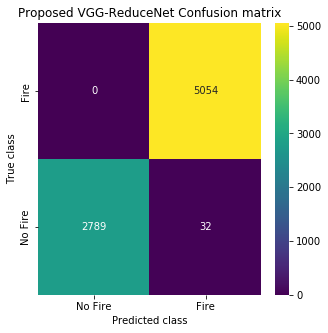

In [10]:
vgg = VGG16(include_top=False, weights='imagenet', input_shape=(X_train.shape[1], X_train.shape[2], X_train.shape[3]))

# Freeze VGG16 layers
for layer in vgg.layers:
    layer.trainable = False

# Define custom VGG-ReduceNet model
x = Conv2D(16, (1, 1), activation='relu')(vgg.output)
x = MaxPooling2D(pool_size=(1, 1))(x)
x = Conv2D(16, (1, 1), activation='relu')(x)
x = MaxPooling2D(pool_size=(1, 1))(x)
x = Flatten()(x)
x = Dense(units=128, activation='relu')(x)
output = Dense(units=y_train.shape[1], activation='softmax')(x)

vgg_reduce_net = Model(inputs=vgg.input, outputs=output)

# Compile and train the model
vgg_reduce_net.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
hist = vgg_reduce_net.fit(X_train, y_train, batch_size=64, epochs=20, validation_data=(X_test, y_test), verbose=1)

# Make predictions and calculate metrics
predict = vgg_reduce_net.predict(X_test)
predict = np.argmax(predict, axis=1)
y_label = np.argmax(y_test, axis=1)
calculateMetrics("Proposed VGG-ReduceNet", predict, y_label)

In [11]:
vgg_reduce_net.save('models/vggnet.h5')

# Extension

Epoch 1/20
493/493 [==============================] - 2s 4ms/step - loss: 0.0811 - accuracy: 0.9731 - val_loss: 0.0443 - val_accuracy: 0.9862
Epoch 2/20
493/493 [==============================] - 2s 4ms/step - loss: 0.0342 - accuracy: 0.9895 - val_loss: 0.0282 - val_accuracy: 0.9914
Epoch 3/20
493/493 [==============================] - 2s 4ms/step - loss: 0.0233 - accuracy: 0.9923 - val_loss: 0.0208 - val_accuracy: 0.9931
Epoch 4/20
493/493 [==============================] - 2s 4ms/step - loss: 0.0195 - accuracy: 0.9935 - val_loss: 0.0284 - val_accuracy: 0.9917
Epoch 5/20
493/493 [==============================] - 2s 4ms/step - loss: 0.0128 - accuracy: 0.9958 - val_loss: 0.0189 - val_accuracy: 0.9947
Epoch 6/20
493/493 [==============================] - 2s 4ms/step - loss: 0.0156 - accuracy: 0.9948 - val_loss: 0.0166 - val_accuracy: 0.9940
Epoch 7/20
493/493 [==============================] - 2s 4ms/step - loss: 0.0114 - accuracy: 0.9961 - val_loss: 0.0136 - val_accuracy: 0.9954
Epoch 

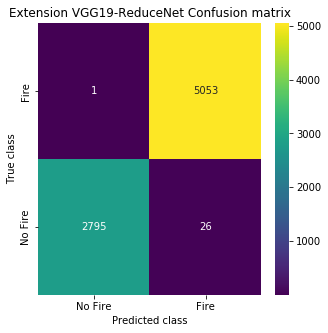

In [12]:
vgg = VGG19(include_top=False, weights='imagenet', input_shape=(X_train.shape[1], X_train.shape[2], X_train.shape[3]))

# Freeze VGG19 layers
for layer in vgg.layers:
    layer.trainable = False

# Define custom VGG-ReduceNet extension model
x = Conv2D(32, (1, 1), activation='relu')(vgg.output)
x = MaxPooling2D(pool_size=(1, 1))(x)
x = Conv2D(32, (1, 1), activation='relu')(x)
x = MaxPooling2D(pool_size=(1, 1))(x)
x = Flatten()(x)
x = Dense(units=256, activation='relu')(x)
output = Dense(units=y_train.shape[1], activation='softmax')(x)

vgg_extension_net = Model(inputs=vgg.input, outputs=output)

# Compile and train the model
vgg_extension_net.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
hist = vgg_extension_net.fit(X_train, y_train, batch_size=64, epochs=20, validation_data=(X_test, y_test), verbose=1)

# Make predictions and calculate metrics
predict = vgg_extension_net.predict(X_test)
predict = np.argmax(predict, axis=1)
y_label = np.argmax(y_test, axis=1)
calculateMetrics("Extension VGG19-ReduceNet", predict, y_label)

In [13]:
vgg_extension_net.save('models/vggnet_extension.h5')

# Comparison

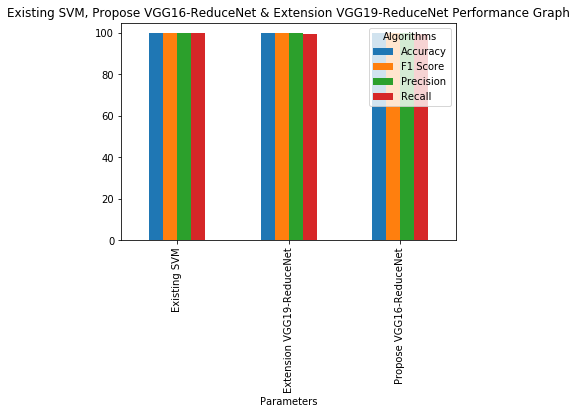

In [14]:
import pandas as pd
df = pd.DataFrame([['Existing SVM','Precision',precision[0]],['Existing SVM','Recall',recall[0]],['Existing SVM','F1 Score',fscore[0]],['Existing SVM','Accuracy',accuracy[0]],
                   ['Propose VGG16-ReduceNet','Precision',precision[1]],['Propose VGG16-ReduceNet','Recall',recall[1]],['Propose VGG16-ReduceNet','F1 Score',fscore[1]],['Propose VGG16-ReduceNet','Accuracy',accuracy[1]],
                   ['Extension VGG19-ReduceNet','Precision',precision[2]],['Extension VGG19-ReduceNet','Recall',recall[2]],['Extension VGG19-ReduceNet','F1 Score',fscore[2]],['Extension VGG19-ReduceNet','Accuracy',accuracy[2]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar')
plt.title("Existing SVM, Propose VGG16-ReduceNet & Extension VGG19-ReduceNet Performance Graph")
plt.show()

In [15]:
#showing all algorithms with scenario A and B performance values
columns = ["Algorithm Name","Precison","Recall","FScore","Accuracy"]
values = []
algorithm_names = ["Existing SVM","Propose VGG16 ReduceNet", "Extension VGG19 ReduceNet"]
for i in range(len(algorithm_names)):
    values.append([algorithm_names[i],precision[i],recall[i],fscore[i],accuracy[i]])
    
temp = pd.DataFrame(values,columns=columns)
temp

,Algorithm Name,Precison,Recall,FScore,Accuracy
0,Existing SVM,99.790620,99.712288,99.751248,99.771429
1,Propose VGG16 ReduceNet,99.685411,99.432825,99.557004,99.593651
2,Extension VGG19 ReduceNet,99.726161,99.529277,99.626430,99.657143


In [16]:
def vibeAnnotate(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower_red = np.array([0, 10, 120])
    upper_red = np.array([15, 255, 255])
    mask = cv2.inRange (hsv, lower_red, upper_red)
    contours, _ = cv2.findContours(mask.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) > 0:
        for c in contours:
            #red_area = max(contours, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(c)
            if w >= 5 and h >= 10:
                cv2.rectangle(img,(x, y),(x+w, y+h),(0, 0, 255), 2)
    return img                    

In [17]:
#function to predict fire or no fire from images or videos
def predict(test_image):
    labels = ['No Fire', 'Fire']
    #reading test image as img variable
    image = cv2.imread(test_image)
    img = cv2.resize(image, (32,32))
    im2arr = np.array(img)
    im2arr = im2arr.reshape(1,32,32,3)
    img = np.asarray(im2arr)
    img = img.astype('float32')
    img = img/255 #normalizing test image
    predict = vgg_extension_net.predict(img)#now using vgg19 extension to predict as fire or no fire
    predict = np.argmax(predict)
    img = cv2.imread(test_image)
    img = cv2.resize(img, (600,400))
    if predict == 1:
        img = vibeAnnotate(img)
    cv2.putText(img, 'Prediction Output : '+labels[predict]+" Detected", (10, 25),  cv2.FONT_HERSHEY_SIMPLEX,0.7, (255, 0, 0), 2)
    plt.figure(figsize=(8,8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

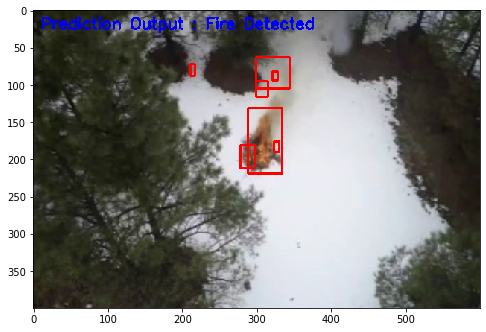

In [18]:
predict("testImages/1.jpg")

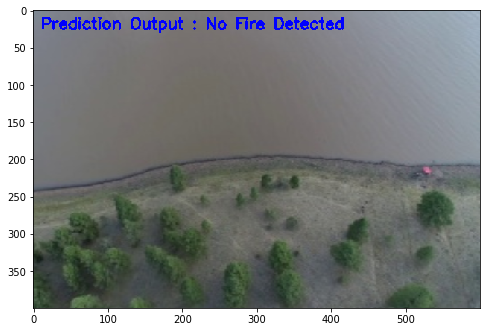

In [19]:
predict("testImages/2.jpg")

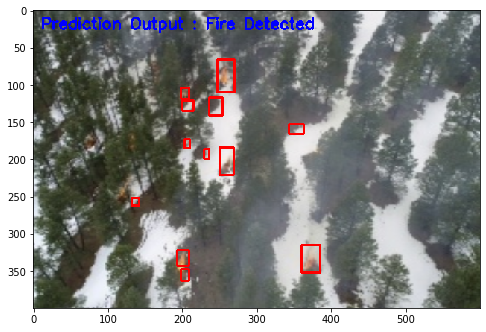

In [20]:
predict("testImages/7.jpg")

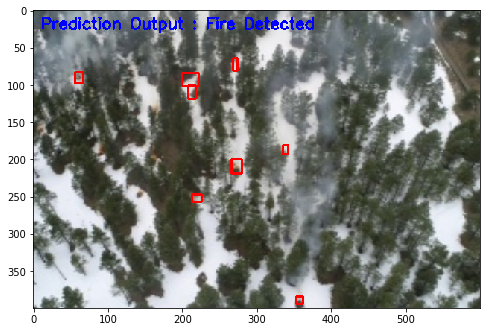

In [21]:
predict("testImages/9.jpg")

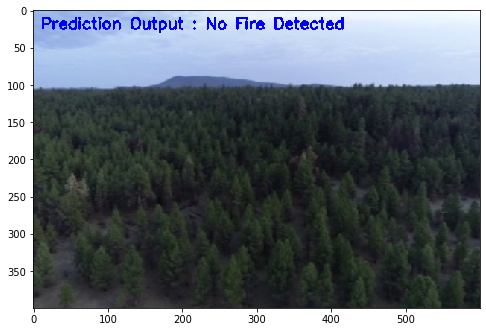

In [22]:
predict("testImages/4.jpg")